# TCGA Breast Cancer Biomarker Discovery Using Machine Learning and Survival Analysis

## Bioinformatics Project

### Author
Gaurav Rabheru

### Overview

This project investigates potential prognostic biomarkers for breast cancer using The Cancer Genome Atlas (TCGA) BRCA RNA sequencing dataset. Differential gene expression analysis, machine learning, and survival analysis were integrated to identify genes associated with patient survival outcomes.

### Objectives

- Identify differentially expressed genes associated with breast cancer.
- Select candidate biomarkers for survival prediction.
- Develop machine learning models to predict patient survival.
- Validate candidate biomarkers using Kaplan-Meier survival analysis and Cox proportional hazards regression.

# Table of Contents

1. Data Loading
2. Data Preprocessing
3. Clinical Data Integration
4. Differential Expression Analysis
5. Biomarker Selection
6. Random Forest Classification
7. Logistic Regression Classification
8. Feature Importance Analysis
9. Survival Analysis
10. Cox Proportional Hazards Regression
11. Machine Learning Evaluation
12. Results
13. Discussion
14. Conclusion

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

# Better looking plots
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
expression = pd.read_csv(
    "../data/raw/TCGA-BRCA.star_fpkm.tsv.gz",
    sep="\t",
    compression="gzip"
)

In [4]:
expression.head()


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,3.061880,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800
1,ENSG00000000005.6,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.037453,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212
2,ENSG00000000419.13,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.533395,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261
3,ENSG00000000457.14,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.238512,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108
4,ENSG00000000460.17,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.210015,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719


In [5]:
expression.shape

(60660, 1227)

In [6]:
expression.info()


<class 'pandas.DataFrame'>
RangeIndex: 60660 entries, 0 to 60659
Columns: 1227 entries, Ensembl_ID to TCGA-A1-A0SN-01A
dtypes: float64(1226), str(1)
memory usage: 567.9 MB


In [7]:
expression_original = expression.copy()

In [8]:
expression["Ensembl_ID"] = (
    expression["Ensembl_ID"]
    .str.split(".")
    .str[0]
)

In [9]:
expression.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,3.061880,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800
1,ENSG00000000005,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.037453,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212
2,ENSG00000000419,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.533395,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261
3,ENSG00000000457,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.238512,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108
4,ENSG00000000460,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.210015,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719


In [10]:
expression.isnull().sum().sum()

np.int64(0)

In [11]:
expression["Ensembl_ID"].duplicated().sum()

np.int64(44)

In [12]:
duplicates = expression[
    expression["Ensembl_ID"].duplicated(keep=False)
]

duplicates.head(20)

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
23,ENSG00000002586,5.750030,5.535789,4.503978,4.986789,3.334740,6.461786,5.721693,5.014721,4.687212,...,5.887506,5.872238,5.616243,4.548788,4.093231,5.620959,5.579835,3.990265,4.830098,5.439630
24,ENSG00000002586,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5507,ENSG00000124333,4.454426,4.660415,4.740944,4.577755,5.030438,4.627893,4.625569,5.101415,4.397324,...,4.515958,4.105670,5.784247,5.323035,4.277300,4.630662,4.145188,4.002306,4.693336,4.920217
5508,ENSG00000124333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5509,ENSG00000124334,0.058940,0.063089,0.107956,0.413377,0.023894,0.011209,0.130272,0.039138,0.126973,...,0.118094,0.307429,0.229711,0.083656,0.308128,0.030689,0.240375,0.027862,0.244035,0.510152
5510,ENSG00000124334,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12082,ENSG00000167393,1.249870,0.693052,1.191436,0.970927,1.217107,3.064917,1.307079,0.763242,0.971810,...,1.315624,1.188338,1.267236,0.575796,1.502280,1.097948,1.109962,1.519592,1.292546,1.120485
12083,ENSG00000167393,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12508,ENSG00000169084,3.200834,3.120369,3.386852,3.211168,2.740712,3.652314,3.223994,2.822710,1.836005,...,3.270529,3.711275,3.154178,2.520774,3.293679,2.319242,2.428839,3.040927,3.086546,3.200457
12509,ENSG00000169084,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [13]:
expression = expression.drop_duplicates(
    subset="Ensembl_ID",
    keep="first"
)

In [14]:
expression["Ensembl_ID"].duplicated().sum()

np.int64(0)

In [15]:
expression.shape

(60616, 1227)

# Gene Annotation

Convert Ensembl gene identifiers into standard human gene symbols using Ensembl BioMart.

**Objective**

- Improve interpretability of the dataset.
- Enable biological interpretation.
- Prepare the dataset for downstream biomarker discovery.

In [16]:
from pybiomart import Dataset

In [17]:
dataset = Dataset(
    name="hsapiens_gene_ensembl",
    host="http://www.ensembl.org"
)

In [18]:
annotation = dataset.query(
    attributes=[
        "ensembl_gene_id",
        "external_gene_name"
    ]
)

In [19]:
annotation.head()

,Gene stable ID,Gene name
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [20]:
annotation.columns = ["Ensembl_ID", "Gene_Symbol"]

annotation.head()

,Ensembl_ID,Gene_Symbol
0,ENSG00000210049,MT-TF
1,ENSG00000211459,MT-RNR1
2,ENSG00000210077,MT-TV
3,ENSG00000210082,MT-RNR2
4,ENSG00000209082,MT-TL1


In [21]:
expression = expression.merge(
    annotation,
    on="Ensembl_ID",
    how="left"
)

In [22]:
expression.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
0,ENSG00000000003,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800,TSPAN6
1,ENSG00000000005,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212,TNMD
2,ENSG00000000419,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261,DPM1
3,ENSG00000000457,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108,SCYL3
4,ENSG00000000460,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719,FIRRM


In [23]:
expression["Gene_Symbol"].notna().sum()

np.int64(42878)

In [24]:
expression = expression.dropna(subset=["Gene_Symbol"])

expression.shape

(42878, 1228)

In [26]:
expression.to_csv(
    "../data/processed/TCGA_BRCA_expression_annotated.csv",
    index=False
)

print("Annotated expression dataset saved successfully!")

Annotated expression dataset saved successfully!


## Clinical Data Processing

### Objective

Load and explore the TCGA BRCA clinical dataset to identify patient characteristics and prepare the data for integration with gene expression profiles.

In [29]:
clinical = pd.read_csv(
    "../data/metadata/TCGA-BRCA.clinical.tsv.gz",
    sep="\t",
    compression="gzip"
)

In [30]:
clinical.shape

(1255, 85)

In [31]:
clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 85 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     1255 non-null   str    
 1   id                                                         1255 non-null   str    
 2   disease_type                                               1255 non-null   str    
 3   case_id                                                    1255 non-null   str    
 4   submitter_id                                               1255 non-null   str    
 5   primary_site                                               1255 non-null   str    
 6   alcohol_history.exposures                                  1254 non-null   str    
 7   race.demographic                                           1254 non-null   str    
 8   gender.demographic 

In [33]:
clinical.columns.tolist()

['sample',
 'id',
 'disease_type',
 'case_id',
 'submitter_id',
 'primary_site',
 'alcohol_history.exposures',
 'race.demographic',
 'gender.demographic',
 'ethnicity.demographic',
 'vital_status.demographic',
 'age_at_index.demographic',
 'days_to_birth.demographic',
 'year_of_birth.demographic',
 'year_of_death.demographic',
 'primary_site.project',
 'project_id.project',
 'disease_type.project',
 'name.project',
 'name.program.project',
 'tissue_source_site_id.tissue_source_site',
 'code.tissue_source_site',
 'name.tissue_source_site',
 'project.tissue_source_site',
 'bcr_id.tissue_source_site',
 'days_to_death.demographic',
 'entity_submitter_id.annotations',
 'notes.annotations',
 'submitter_id.annotations',
 'classification.annotations',
 'entity_id.annotations',
 'created_datetime.annotations',
 'annotation_id.annotations',
 'entity_type.annotations',
 'updated_datetime.annotations',
 'case_id.annotations',
 'state.annotations',
 'category.annotations',
 'status.annotations',
 '

In [34]:
clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].head()

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-BH-A0W3,Alive,58.0,female,white
1,TCGA-AR-A24V,Alive,52.0,female,white
2,TCGA-E9-A1NE,Alive,28.0,female,white
3,TCGA-E9-A1NE,Alive,28.0,female,white
4,TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [35]:
clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].isnull().sum()

submitter_id                0
vital_status.demographic    1
age_at_index.demographic    1
gender.demographic          1
race.demographic            1
dtype: int64

In [36]:
clinical_clean = clinical[
    [
        "submitter_id",
        "vital_status.demographic",
        "age_at_index.demographic",
        "gender.demographic",
        "race.demographic",
    ]
].dropna()

In [37]:
clinical_clean.shape

(1254, 5)

In [38]:
clinical_clean.head()

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-BH-A0W3,Alive,58.0,female,white
1,TCGA-AR-A24V,Alive,52.0,female,white
2,TCGA-E9-A1NE,Alive,28.0,female,white
3,TCGA-E9-A1NE,Alive,28.0,female,white
4,TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [39]:
sample_columns = expression.columns[1:-1]

patient_ids = [sample[:12] for sample in sample_columns]

print(patient_ids[:5])

['TCGA-D8-A146', 'TCGA-AQ-A0Y5', 'TCGA-C8-A274', 'TCGA-BH-A0BD', 'TCGA-B6-A1KC']


In [40]:
common_patients = set(patient_ids).intersection(
    set(clinical_clean["submitter_id"])
)

print(f"Common patients: {len(common_patients)}")

Common patients: 1094


In [41]:
clinical_clean.to_csv(
    "../data/processed/TCGA_BRCA_clinical_clean.csv",
    index=False
)

print("Clinical dataset saved successfully!")

Clinical dataset saved successfully!


In [42]:
clinical_lookup = clinical_clean.set_index("submitter_id")

clinical_lookup.head()

,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
submitter_id,,,,
TCGA-BH-A0W3,Alive,58.0,female,white
TCGA-AR-A24V,Alive,52.0,female,white
TCGA-E9-A1NE,Alive,28.0,female,white
TCGA-E9-A1NE,Alive,28.0,female,white
TCGA-AC-A8OQ,Alive,72.0,female,black or african american


In [43]:
clinical_lookup.loc["TCGA-BH-A0W3"]

vital_status.demographic     Alive
age_at_index.demographic      58.0
gender.demographic          female
race.demographic             white
Name: TCGA-BH-A0W3, dtype: object

In [44]:
"TCGA-BH-A0W3" in clinical_lookup.index

True

In [46]:
clinical_clean["submitter_id"].duplicated().sum()

np.int64(157)

In [47]:
clinical_clean[
    clinical_clean["submitter_id"].duplicated(keep=False)
].sort_values("submitter_id")

,submitter_id,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
315,TCGA-A7-A0CE,Alive,57.0,female,white
314,TCGA-A7-A0CE,Alive,57.0,female,white
318,TCGA-A7-A0CH,Alive,79.0,female,white
317,TCGA-A7-A0CH,Alive,79.0,female,white
1254,TCGA-A7-A0D9,Alive,37.0,female,white
...,...,...,...,...,...
699,TCGA-GI-A2C8,Alive,63.0,female,white
940,TCGA-GI-A2C9,Alive,58.0,female,black or african american
941,TCGA-GI-A2C9,Alive,58.0,female,black or african american
557,TCGA-XX-A899,Alive,46.0,female,white


In [48]:
clinical_clean = clinical_clean.drop_duplicates(subset="submitter_id")

In [49]:
clinical_clean["submitter_id"].duplicated().sum()

np.int64(0)

In [50]:
clinical_lookup = clinical_clean.set_index("submitter_id")

In [51]:
matched_clinical = clinical_lookup.reindex(patient_ids)

In [52]:
matched_clinical.shape

(1226, 4)

In [53]:
matched_clinical.notna().all(axis=1).sum()

np.int64(1225)

# Exploratory Data Analysis (EDA)

## Objective

Now that the gene expression and clinical datasets have been cleaned and integrated, we will explore the data through summary statistics and visualizations. This helps us understand patient characteristics, identify patterns, detect potential outliers, and generate hypotheses before performing biomarker discovery and statistical analyses.

## 1. Patient Demographics

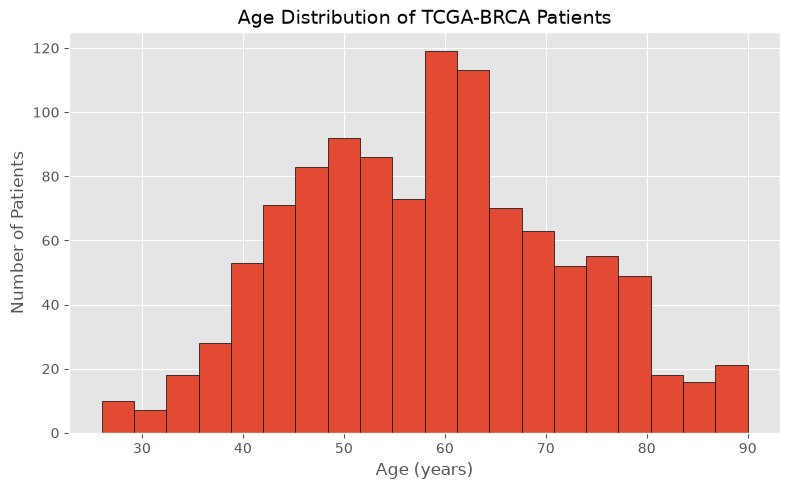

In [58]:
plt.figure(figsize=(8,5))

plt.hist(
    clinical_clean["age_at_index.demographic"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution of TCGA-BRCA Patients", fontsize=14)
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.show()

## 2. Vital Status Distribution

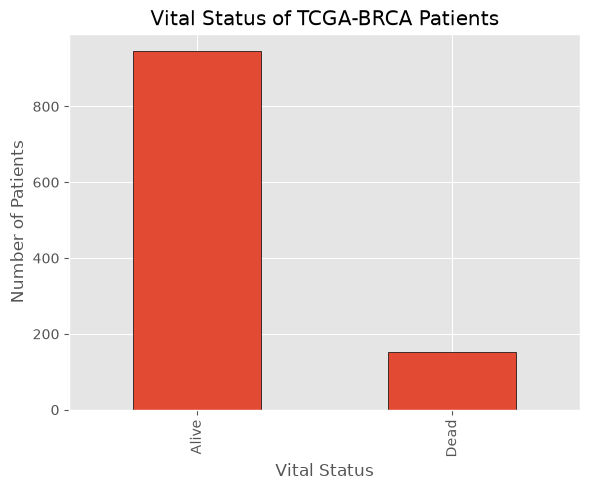

In [59]:
plt.figure(figsize=(6,5))

clinical_clean["vital_status.demographic"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Vital Status of TCGA-BRCA Patients")
plt.xlabel("Vital Status")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/vital_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Gender Distribution

Visualize the distribution of patient gender within the TCGA-BRCA cohort.

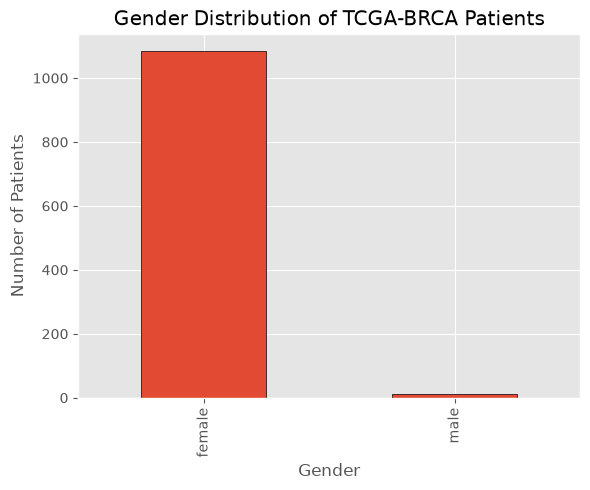

In [60]:
plt.figure(figsize=(6,5))

clinical_clean["gender.demographic"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Gender Distribution of TCGA-BRCA Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Expression of TP53

TP53 is a well-known tumor suppressor gene involved in regulating cell growth and preventing the accumulation of DNA damage. Here, we examine its expression across the TCGA-BRCA cohort.

In [67]:
expression[expression["Gene_Symbol"] == "TP53"]

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
8121,ENSG00000141510,3.655386,3.304263,4.243738,4.410416,3.838962,3.350724,3.95939,3.405107,4.156995,...,3.641396,3.806891,3.86844,4.536569,3.187562,2.991916,3.438532,4.864444,4.22064,TP53


In [68]:
tp53 = expression[expression["Gene_Symbol"] == "TP53"]

tp53

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
8121,ENSG00000141510,3.655386,3.304263,4.243738,4.410416,3.838962,3.350724,3.95939,3.405107,4.156995,...,3.641396,3.806891,3.86844,4.536569,3.187562,2.991916,3.438532,4.864444,4.22064,TP53


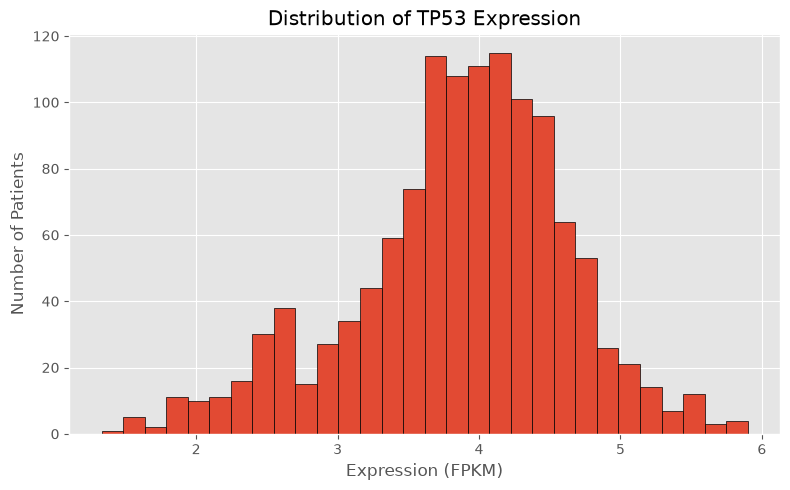

In [69]:
# Extract TP53 expression values
tp53_values = tp53.iloc[0, 1:-1]

# Convert to numeric values
tp53_values = pd.to_numeric(tp53_values)

# Create histogram
plt.figure(figsize=(8,5))

plt.hist(tp53_values, bins=30, edgecolor="black")

plt.title("Distribution of TP53 Expression")
plt.xlabel("Expression (FPKM)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/tp53_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
tp53_df = pd.DataFrame({
    "submitter_id": patient_ids,
    "TP53_expression": tp53_values.values
})

tp53_df.head()

,submitter_id,TP53_expression
0,TCGA-D8-A146,3.655386
1,TCGA-AQ-A0Y5,3.304263
2,TCGA-C8-A274,4.243738
3,TCGA-BH-A0BD,4.410416
4,TCGA-B6-A1KC,3.838962


In [72]:
tp53_clinical = tp53_df.merge(
    clinical_clean,
    on="submitter_id",
    how="inner"
)

tp53_clinical.head()

,submitter_id,TP53_expression,vital_status.demographic,age_at_index.demographic,gender.demographic,race.demographic
0,TCGA-D8-A146,3.655386,Alive,57.0,female,white
1,TCGA-AQ-A0Y5,3.304263,Dead,70.0,female,white
2,TCGA-C8-A274,4.243738,Alive,63.0,female,asian
3,TCGA-BH-A0BD,4.410416,Alive,47.0,female,white
4,TCGA-B6-A1KC,3.838962,Alive,67.0,female,white


In [73]:
tp53_clinical.shape

(1225, 6)

## 6. TP53 Expression by Vital Status

Compare TP53 expression between patients who were alive and deceased at the time of data collection.

<Figure size 700x500 with 0 Axes>

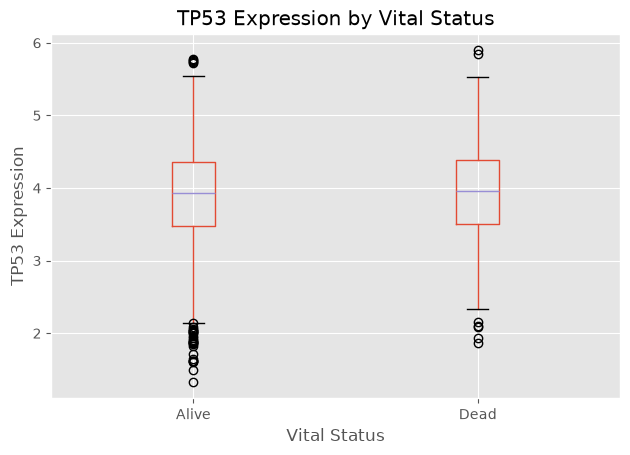

In [74]:
plt.figure(figsize=(7,5))

tp53_clinical.boxplot(
    column="TP53_expression",
    by="vital_status.demographic"
)

plt.title("TP53 Expression by Vital Status")
plt.suptitle("")  # Removes the default pandas title
plt.xlabel("Vital Status")
plt.ylabel("TP53 Expression")

plt.tight_layout()

plt.savefig(
    "../results/figures/tp53_by_vital_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Expression of BRCA1

BRCA1 is a tumor suppressor gene involved in DNA repair. Alterations in BRCA1 are associated with hereditary breast and ovarian cancer. Here, we examine BRCA1 expression across TCGA-BRCA patients.

In [75]:
brca1 = expression[expression["Gene_Symbol"] == "BRCA1"]

brca1

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
309,ENSG00000012048,1.026375,1.043624,1.94182,2.254927,2.311736,1.396598,0.898711,2.214249,1.535207,...,1.100305,2.176131,1.503145,2.060047,1.740884,1.369885,2.769539,1.874246,1.839798,BRCA1


In [77]:
brca1_values = brca1.iloc[0, 1:-1]

brca1_values = pd.to_numeric(brca1_values)

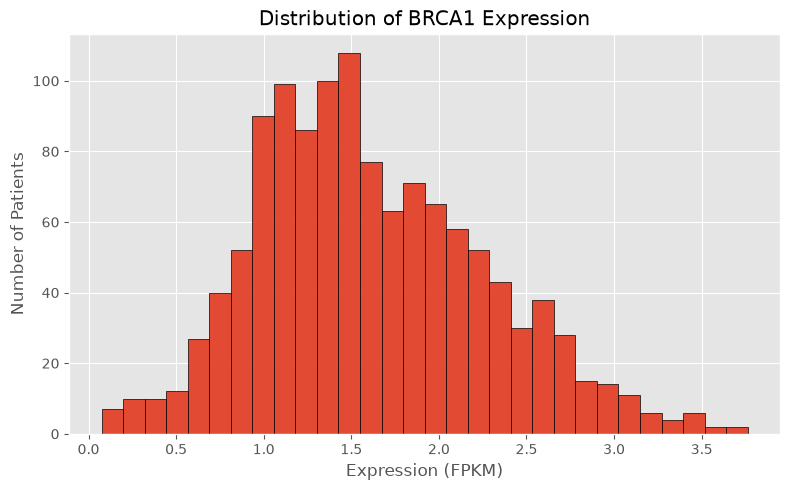

In [78]:
plt.figure(figsize=(8,5))

plt.hist(
    brca1_values,
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of BRCA1 Expression")
plt.xlabel("Expression (FPKM)")
plt.ylabel("Number of Patients")

plt.tight_layout()

plt.savefig(
    "../results/figures/brca1_expression_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 700x500 with 0 Axes>

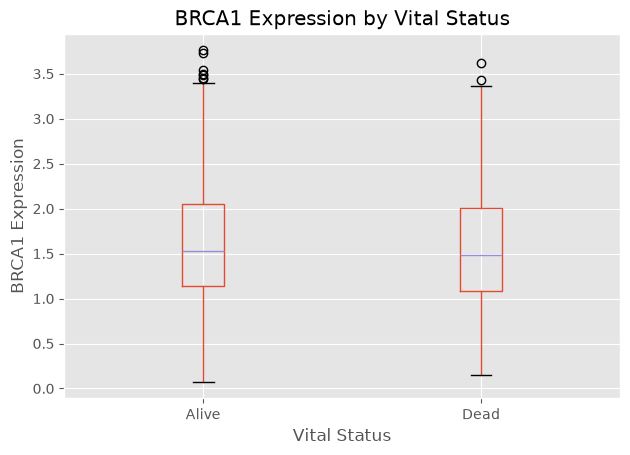

In [79]:
brca1_df = pd.DataFrame({
    "submitter_id": patient_ids,
    "BRCA1_expression": brca1_values.values
})

brca1_clinical = brca1_df.merge(
    clinical_clean,
    on="submitter_id",
    how="inner"
)

plt.figure(figsize=(7,5))

brca1_clinical.boxplot(
    column="BRCA1_expression",
    by="vital_status.demographic"
)

plt.title("BRCA1 Expression by Vital Status")
plt.suptitle("")
plt.xlabel("Vital Status")
plt.ylabel("BRCA1 Expression")

plt.tight_layout()

plt.savefig(
    "../results/figures/brca1_by_vital_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

BRCA1 expression showed a similar distribution between patients who were alive and those who were deceased. The median expression and variability were comparable in both groups, and considerable overlap was observed. Although a few high-expression outliers were present, visual inspection alone does not suggest a strong association between BRCA1 expression and patient survival. Statistical testing will be performed later to evaluate this formally.

## 8. Reusable Functions for Gene Expression Analysis

To avoid repetitive code, reusable functions are created to visualize the expression of any gene across the TCGA-BRCA cohort and compare its expression between patient groups.

In [80]:
def plot_gene_distribution(gene_symbol):
    """
    Plot the distribution of expression values for a given gene.
    """

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    if gene.empty:
        print(f"{gene_symbol} not found.")
        return

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    plt.figure(figsize=(8,5))

    plt.hist(
        values,
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {gene_symbol} Expression")
    plt.xlabel("Expression (FPKM)")
    plt.ylabel("Number of Patients")

    plt.tight_layout()
    plt.show()

In [81]:
def plot_gene_by_vital_status(gene_symbol):
    """
    Compare gene expression between Alive and Dead patients.
    """

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    if gene.empty:
        print(f"{gene_symbol} not found.")
        return

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    plt.figure(figsize=(7,5))

    merged.boxplot(
        column="Expression",
        by="vital_status.demographic"
    )

    plt.title(f"{gene_symbol} Expression by Vital Status")
    plt.suptitle("")
    plt.xlabel("Vital Status")
    plt.ylabel("Expression (FPKM)")

    plt.tight_layout()
    plt.show()

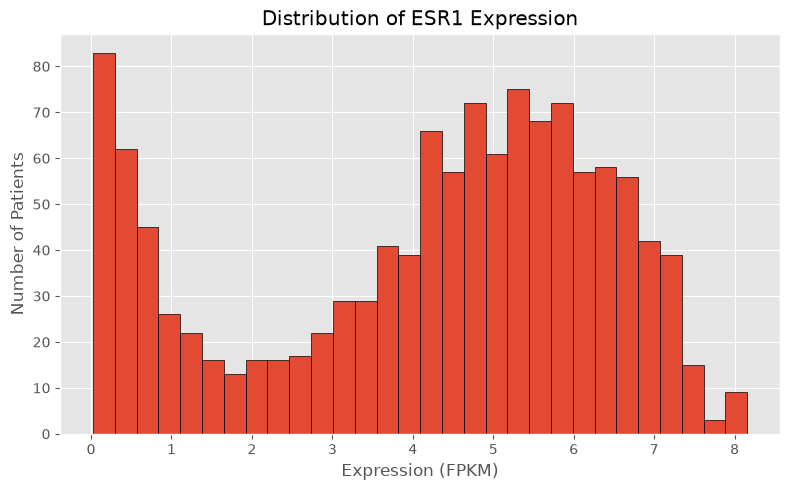

<Figure size 700x500 with 0 Axes>

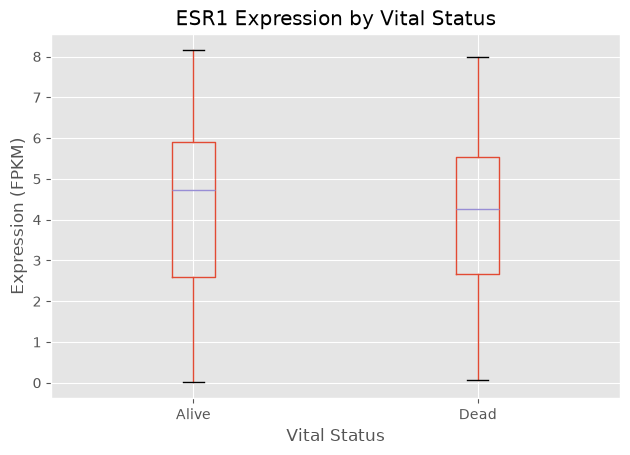

In [82]:
plot_gene_distribution("ESR1")
plot_gene_by_vital_status("ESR1")

## 8.1 ESR1 Expression Analysis

ESR1 encodes the estrogen receptor alpha, a key biomarker in breast cancer. High ESR1 expression is commonly associated with estrogen receptor-positive tumors and guides the use of endocrine therapies.

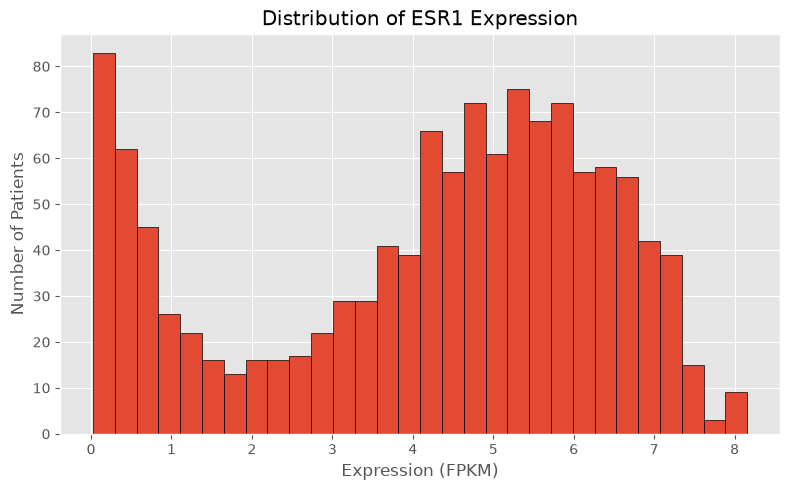

<Figure size 700x500 with 0 Axes>

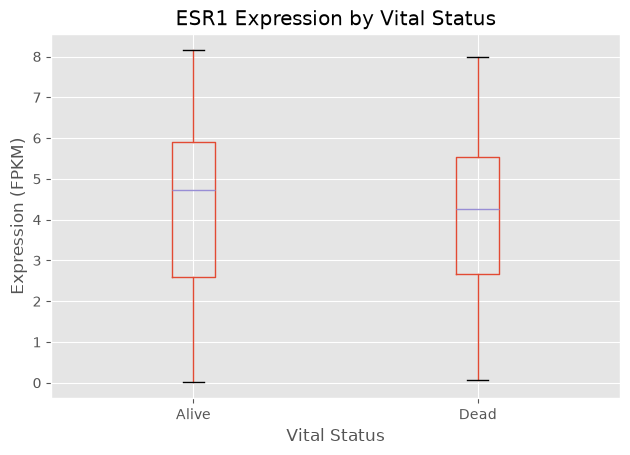

In [86]:
plot_gene_distribution("ESR1")
plot_gene_by_vital_status("ESR1")

## 8.2 ERBB2 (HER2) Expression Analysis

ERBB2 (HER2) is an oncogene that is overexpressed in a subset of breast cancers. HER2 status is routinely used to guide targeted therapy and is an important clinical biomarker.

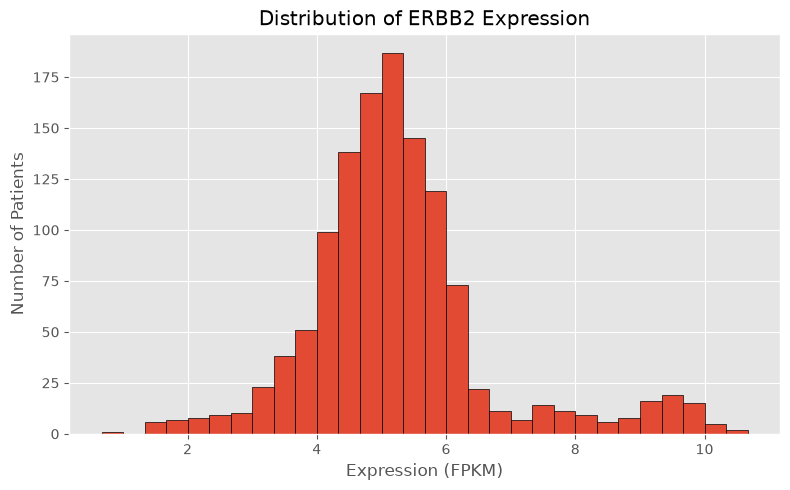

<Figure size 700x500 with 0 Axes>

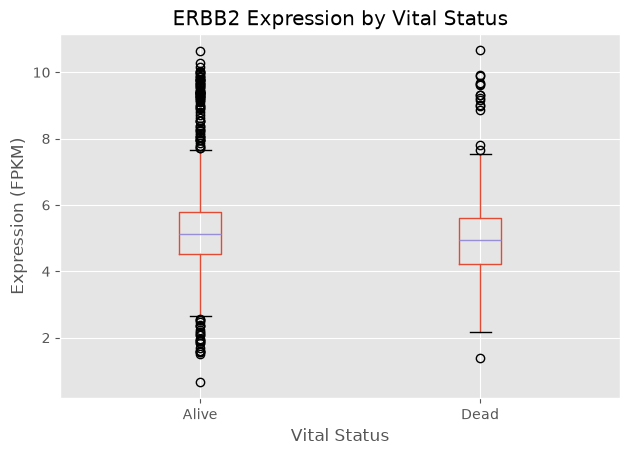

In [87]:
plot_gene_distribution("ERBB2")
plot_gene_by_vital_status("ERBB2")

# 9. Statistical Analysis

Visual differences between groups do not necessarily indicate statistically significant differences. Therefore, the Mann–Whitney U test was used to compare gene expression between patients who were alive and deceased.

In [88]:
from scipy.stats import mannwhitneyu

In [89]:
def mann_whitney_test(gene_symbol):

    gene = expression[expression["Gene_Symbol"] == gene_symbol]

    values = pd.to_numeric(gene.iloc[0, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    alive = merged[
        merged["vital_status.demographic"] == "Alive"
    ]["Expression"]

    dead = merged[
        merged["vital_status.demographic"] == "Dead"
    ]["Expression"]

    statistic, p = mannwhitneyu(
        alive,
        dead,
        alternative="two-sided"
    )

    print(f"\nGene: {gene_symbol}")
    print(f"U statistic: {statistic:.2f}")
    print(f"P-value: {p:.5f}")

    if p < 0.05:
        print("Result: Statistically significant difference.")
    else:
        print("Result: No statistically significant difference.")

In [90]:
mann_whitney_test("TP53")
mann_whitney_test("BRCA1")
mann_whitney_test("ESR1")
mann_whitney_test("ERBB2")


Gene: TP53
U statistic: 99792.00
P-value: 0.55411
Result: No statistically significant difference.

Gene: BRCA1
U statistic: 106368.50
P-value: 0.39800
Result: No statistically significant difference.

Gene: ESR1
U statistic: 110245.00
P-value: 0.09060
Result: No statistically significant difference.

Gene: ERBB2
U statistic: 113970.00
P-value: 0.01220
Result: Statistically significant difference.


## Statistical Summary

The Mann–Whitney U test was used to compare gene expression between patients who were alive and deceased.

| Gene | P-value | Interpretation |
|------|---------:|---------------|
| TP53 | 0.554 | No significant difference |
| BRCA1 | 0.398 | No significant difference |
| ESR1 | 0.091 | No significant difference |
| ERBB2 | 0.012 | Significant difference |

Among the four genes examined, only **ERBB2** showed a statistically significant difference in expression between the two patient groups (p < 0.05). TP53, BRCA1, and ESR1 did not show statistically significant differences in this comparison.

## 10.1 Genome-wide Mann–Whitney U Testing

Each annotated gene was compared between patients who were alive and deceased using the Mann–Whitney U test. The resulting p-values were collected for all genes to identify potential survival-associated biomarkers.

In [93]:
results = []

for i in range(len(expression)):

    gene_symbol = expression.iloc[i]["Gene_Symbol"]

    values = pd.to_numeric(expression.iloc[i, 1:-1])

    gene_df = pd.DataFrame({
        "submitter_id": patient_ids,
        "Expression": values.values
    })

    merged = gene_df.merge(
        clinical_clean,
        on="submitter_id",
        how="inner"
    )

    alive = merged[
        merged["vital_status.demographic"] == "Alive"
    ]["Expression"]

    dead = merged[
        merged["vital_status.demographic"] == "Dead"
    ]["Expression"]

    statistic, p = mannwhitneyu(
        alive,
        dead,
        alternative="two-sided"
    )

    results.append([
        gene_symbol,
        statistic,
        p
    ])

In [94]:
len(results)

42878

In [95]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Gene_Symbol",
        "U_statistic",
        "P_value"
    ]
)

results_df.head()

,Gene_Symbol,U_statistic,P_value
0,TSPAN6,92628.0,0.031005
1,TNMD,91102.0,0.012740
2,DPM1,102100.0,0.930438
3,SCYL3,107942.5,0.234391
4,FIRRM,109945.0,0.103804


In [97]:
from statsmodels.stats.multitest import multipletests

In [98]:
results_df["FDR"] = multipletests(
    results_df["P_value"],
    method="fdr_bh"
)[1]

results_df.head()

,Gene_Symbol,U_statistic,P_value,FDR
0,TSPAN6,92628.0,0.031005,NaN
1,TNMD,91102.0,0.012740,NaN
2,DPM1,102100.0,0.930438,NaN
3,SCYL3,107942.5,0.234391,NaN
4,FIRRM,109945.0,0.103804,NaN


In [99]:
results_df = results_df.sort_values(
    "FDR"
)

results_df.head(20)

,Gene_Symbol,U_statistic,P_value,FDR
0,TSPAN6,92628.0,0.031005,NaN
1,TNMD,91102.0,0.012740,NaN
2,DPM1,102100.0,0.930438,NaN
3,SCYL3,107942.5,0.234391,NaN
4,FIRRM,109945.0,0.103804,NaN
5,FGR,103782.5,0.779379,NaN
6,CFH,90039.0,0.006475,NaN
7,FUCA2,100099.5,0.599986,NaN
8,GCLC,90474.5,0.008600,NaN
9,NFYA,103302.0,0.860974,NaN


In [101]:
results_df["P_value"].isna().sum()
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42878 entries, 0 to 42877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gene_Symbol  42878 non-null  str    
 1   U_statistic  42878 non-null  float64
 2   P_value      41513 non-null  float64
 3   FDR          0 non-null      float64
dtypes: float64(3), str(1)
memory usage: 1.3 MB


In [102]:
results_df["P_value"].describe()
results_df[results_df["P_value"].isna()].head()

,Gene_Symbol,U_statistic,P_value,FDR
277,NME1-NME2,102500.0,NaN,NaN
2584,MCTS2,102500.0,NaN,NaN
2811,CORO7-PAM16,102500.0,NaN,NaN
3083,ICAM4,102500.0,NaN,NaN
5469,PEDS1-UBE2V1,102500.0,NaN,NaN


In [103]:
results_df = results_df.dropna(subset=["P_value"]).copy()

print(results_df.shape)

(41513, 4)


In [104]:
results_df["FDR"] = multipletests(
    results_df["P_value"],
    method="fdr_bh"
)[1]

In [105]:
results_df = results_df.sort_values("FDR")

results_df.head(20)

,Gene_Symbol,U_statistic,P_value,FDR
39855,LINC01235,73517.5,2.407276e-10,0.000010
434,DEF6,129611.5,3.142309e-09,0.000036
9806,KLF10,75169.0,2.344369e-09,0.000036
5814,SBDS,75468.0,3.492102e-09,0.000036
13434,ZBTB21,76189.0,8.973588e-09,0.000044
4442,CHMP3,76093.0,7.924972e-09,0.000044
3503,UBTF,129054.0,6.546328e-09,0.000044
19924,LINC00583,89530.0,9.555450e-09,0.000044
10148,PRXL2C,76044.0,7.436683e-09,0.000044
13431,MZT2A,128458.0,1.411927e-08,0.000055


In [106]:
results_df.info()

<class 'pandas.DataFrame'>
Index: 41513 entries, 39855 to 29003
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gene_Symbol  41513 non-null  str    
 1   U_statistic  41513 non-null  float64
 2   P_value      41513 non-null  float64
 3   FDR          41513 non-null  float64
dtypes: float64(3), str(1)
memory usage: 1.6 MB


# 11. Machine Learning Dataset Preparation

To build a predictive model, the most statistically significant genes identified in the genome-wide analysis were selected as candidate biomarkers. These genes were used as features for classifying patient survival status.

In [107]:
top_genes = results_df.head(20)["Gene_Symbol"].tolist()

top_genes

['LINC01235',
 'DEF6',
 'KLF10',
 'SBDS',
 'ZBTB21',
 'CHMP3',
 'UBTF',
 'LINC00583',
 'PRXL2C',
 'MZT2A',
 'BICRA-AS2',
 'MTFP1',
 'SIAH2',
 'TMEM43',
 'RHBDL1',
 'SNX3',
 'LRRC45',
 'C2CD2',
 'LEF1',
 'LEF1-AS1']

In [108]:
ml_expression = expression[
    expression["Gene_Symbol"].isin(top_genes)
]

ml_expression.shape

(20, 1228)

In [109]:
ml_data = ml_expression.set_index("Gene_Symbol")

ml_data = ml_data.drop(columns=["Ensembl_ID"])

ml_data = ml_data.T

ml_data.head()

Gene_Symbol,DEF6,RHBDL1,UBTF,SNX3,CHMP3,SBDS,LEF1,KLF10,C2CD2,PRXL2C,LRRC45,TMEM43,MZT2A,ZBTB21,SIAH2,LINC00583,LEF1-AS1,MTFP1,LINC01235,BICRA-AS2
TCGA-D8-A146-01A,3.290469,2.334454,4.404883,6.067295,3.793989,5.528087,2.531169,4.467143,2.953731,2.597174,2.923530,4.828936,3.397748,2.355890,6.300704,0.0,0.141302,0.257131,1.240681,0.473423
TCGA-AQ-A0Y5-01A,1.775303,2.637518,4.162734,6.839478,4.138970,5.889315,2.286467,4.043799,2.704009,2.464485,2.167069,4.846303,2.152378,2.121778,3.975034,0.0,0.063089,0.213378,1.684953,0.114234
TCGA-C8-A274-01A,2.706155,0.971590,4.537936,6.019875,4.091446,4.941665,1.031466,3.489209,3.494864,1.712640,2.343379,3.920684,3.285580,2.861876,4.593635,0.0,0.013069,0.165044,0.527170,0.466653
TCGA-BH-A0BD-01A,3.516267,1.875583,4.853926,5.756097,3.953200,5.113413,1.790355,4.878990,2.600151,2.871785,2.778272,4.777215,2.728944,2.118459,5.196595,0.0,0.043904,0.172488,0.720891,0.249142
TCGA-B6-A1KC-01B,2.866750,0.603217,3.880333,5.417765,3.593951,5.447232,1.856986,3.856498,1.534111,1.770068,2.008702,4.921489,1.738119,1.804838,3.309846,0.0,0.086648,0.131721,1.102792,0.632827


In [110]:
ml_data.shape

(1226, 20)

In [111]:
ml_data["submitter_id"] = ml_data.index.str[:12]

ml_data = ml_data.merge(
    clinical_clean[
        ["submitter_id", "vital_status.demographic"]
    ],
    on="submitter_id"
)

ml_data.head()

,DEF6,RHBDL1,UBTF,SNX3,CHMP3,SBDS,LEF1,KLF10,C2CD2,PRXL2C,...,MZT2A,ZBTB21,SIAH2,LINC00583,LEF1-AS1,MTFP1,LINC01235,BICRA-AS2,submitter_id,vital_status.demographic
0,3.290469,2.334454,4.404883,6.067295,3.793989,5.528087,2.531169,4.467143,2.953731,2.597174,...,3.397748,2.355890,6.300704,0.0,0.141302,0.257131,1.240681,0.473423,TCGA-D8-A146,Alive
1,1.775303,2.637518,4.162734,6.839478,4.138970,5.889315,2.286467,4.043799,2.704009,2.464485,...,2.152378,2.121778,3.975034,0.0,0.063089,0.213378,1.684953,0.114234,TCGA-AQ-A0Y5,Dead
2,2.706155,0.971590,4.537936,6.019875,4.091446,4.941665,1.031466,3.489209,3.494864,1.712640,...,3.285580,2.861876,4.593635,0.0,0.013069,0.165044,0.527170,0.466653,TCGA-C8-A274,Alive
3,3.516267,1.875583,4.853926,5.756097,3.953200,5.113413,1.790355,4.878990,2.600151,2.871785,...,2.728944,2.118459,5.196595,0.0,0.043904,0.172488,0.720891,0.249142,TCGA-BH-A0BD,Alive
4,2.866750,0.603217,3.880333,5.417765,3.593951,5.447232,1.856986,3.856498,1.534111,1.770068,...,1.738119,1.804838,3.309846,0.0,0.086648,0.131721,1.102792,0.632827,TCGA-B6-A1KC,Alive


## 11.1 Creating the Prediction Target

The clinical outcome (vital status) was converted into a binary target variable for supervised machine learning.

- Alive = 0
- Dead = 1

In [112]:
ml_data["Target"] = ml_data["vital_status.demographic"].map({
    "Alive": 0,
    "Dead": 1
})

ml_data.head()

,DEF6,RHBDL1,UBTF,SNX3,CHMP3,SBDS,LEF1,KLF10,C2CD2,PRXL2C,...,ZBTB21,SIAH2,LINC00583,LEF1-AS1,MTFP1,LINC01235,BICRA-AS2,submitter_id,vital_status.demographic,Target
0,3.290469,2.334454,4.404883,6.067295,3.793989,5.528087,2.531169,4.467143,2.953731,2.597174,...,2.355890,6.300704,0.0,0.141302,0.257131,1.240681,0.473423,TCGA-D8-A146,Alive,0
1,1.775303,2.637518,4.162734,6.839478,4.138970,5.889315,2.286467,4.043799,2.704009,2.464485,...,2.121778,3.975034,0.0,0.063089,0.213378,1.684953,0.114234,TCGA-AQ-A0Y5,Dead,1
2,2.706155,0.971590,4.537936,6.019875,4.091446,4.941665,1.031466,3.489209,3.494864,1.712640,...,2.861876,4.593635,0.0,0.013069,0.165044,0.527170,0.466653,TCGA-C8-A274,Alive,0
3,3.516267,1.875583,4.853926,5.756097,3.953200,5.113413,1.790355,4.878990,2.600151,2.871785,...,2.118459,5.196595,0.0,0.043904,0.172488,0.720891,0.249142,TCGA-BH-A0BD,Alive,0
4,2.866750,0.603217,3.880333,5.417765,3.593951,5.447232,1.856986,3.856498,1.534111,1.770068,...,1.804838,3.309846,0.0,0.086648,0.131721,1.102792,0.632827,TCGA-B6-A1KC,Alive,0


In [113]:
ml_data["Target"].value_counts()

Target
0    1025
1     200
Name: count, dtype: int64

In [114]:
from sklearn.model_selection import train_test_split

In [115]:
X = ml_data.drop(
    columns=[
        "submitter_id",
        "vital_status.demographic",
        "Target"
    ]
)

y = ml_data["Target"]

In [116]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [117]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(980, 20)
(245, 20)
(980,)
(245,)


# 12. Random Forest Classification

A Random Forest classifier was trained using the top 20 candidate biomarkers to predict patient survival status (Alive vs Dead). Model performance was evaluated on an independent test set.

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [130]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [120]:
predictions = rf_model.predict(X_test)
probabilities = rf_model.predict_proba(X_test)[:, 1]

In [121]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [122]:
print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall   :", recall_score(y_test, predictions))
print("F1 Score :", f1_score(y_test, predictions))
print("ROC AUC  :", roc_auc_score(y_test, probabilities))

Accuracy : 0.8326530612244898
Precision: 0.4666666666666667
Recall   : 0.175
F1 Score : 0.2545454545454545
ROC AUC  : 0.6016463414634146


In [123]:
cm = confusion_matrix(y_test, predictions)

print(cm)

[[197   8]
 [ 33   7]]


# 13. Feature Importance Analysis

Random Forest provides an estimate of feature importance, indicating which genes contributed most to predicting patient survival.

In [142]:
importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Gene,Importance
7,KLF10,0.072951
0,DEF6,0.062088
18,LINC01235,0.057725
5,SBDS,0.057602
9,PRXL2C,0.056577
13,ZBTB21,0.055637
6,LEF1,0.054475
8,C2CD2,0.052237
1,RHBDL1,0.049662
11,TMEM43,0.049496


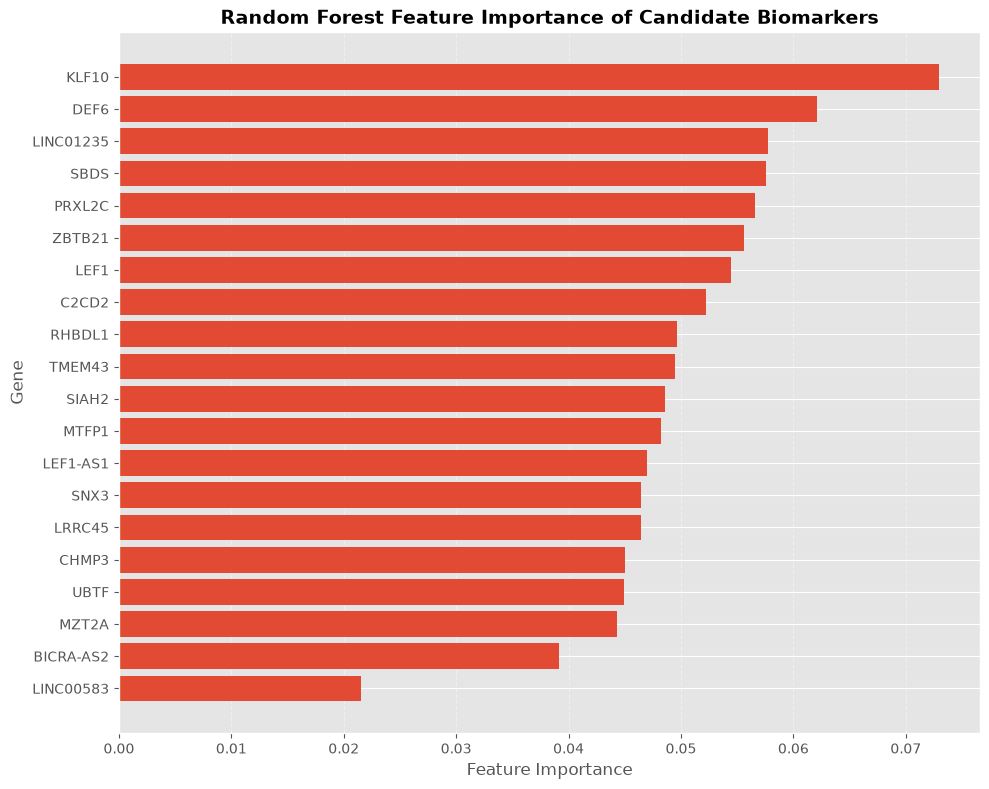

In [185]:
plt.figure(figsize=(10,8))

importance_sorted = importance.sort_values(
    "Importance",
    ascending=True
)

plt.barh(
    importance_sorted["Gene"],
    importance_sorted["Importance"]
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Gene", fontsize=12)

plt.title(
    "Random Forest Feature Importance of Candidate Biomarkers",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [144]:
plt.savefig(
    "../results/figures/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [145]:
ml_genes = importance.head(20)["Gene"]

overlap = set(ml_genes).intersection(set(top_genes))

overlap

{'BICRA-AS2',
 'C2CD2',
 'CHMP3',
 'DEF6',
 'KLF10',
 'LEF1',
 'LEF1-AS1',
 'LINC00583',
 'LINC01235',
 'LRRC45',
 'MTFP1',
 'MZT2A',
 'PRXL2C',
 'RHBDL1',
 'SBDS',
 'SIAH2',
 'SNX3',
 'TMEM43',
 'UBTF',
 'ZBTB21'}

In [146]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

In [147]:
rf_balanced.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [148]:
y_pred_balanced = rf_balanced.predict(X_test)
y_prob_balanced = rf_balanced.predict_proba(X_test)[:,1]

In [149]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("ROC AUC:", roc_auc_score(y_test, y_prob_balanced))

Accuracy: 0.8122448979591836
Precision: 0.35
Recall: 0.175
F1 Score: 0.23333333333333334
ROC AUC: 0.5986585365853658


In [150]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

c:\python\bio_info_pulpy\tcga-biomarker-discovery\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\python\bio_info_pulpy\tcga-biomarker-discovery\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [151]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.6530612244897959
Precision: 0.2413793103448276
Recall: 0.525
F1 Score: 0.33070866141732286
ROC AUC: 0.6168292682926829


In [152]:
coefficients = pd.DataFrame({
    "Gene": X.columns,
    "Coefficient": lr_model.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

coefficients

,Gene,Coefficient
15,LINC00583,1.452342
16,LEF1-AS1,0.280180
13,ZBTB21,0.223156
18,LINC01235,0.208612
7,KLF10,0.186424
8,C2CD2,0.176198
12,MZT2A,0.150016
3,SNX3,0.133074
11,TMEM43,0.084934
9,PRXL2C,0.063347


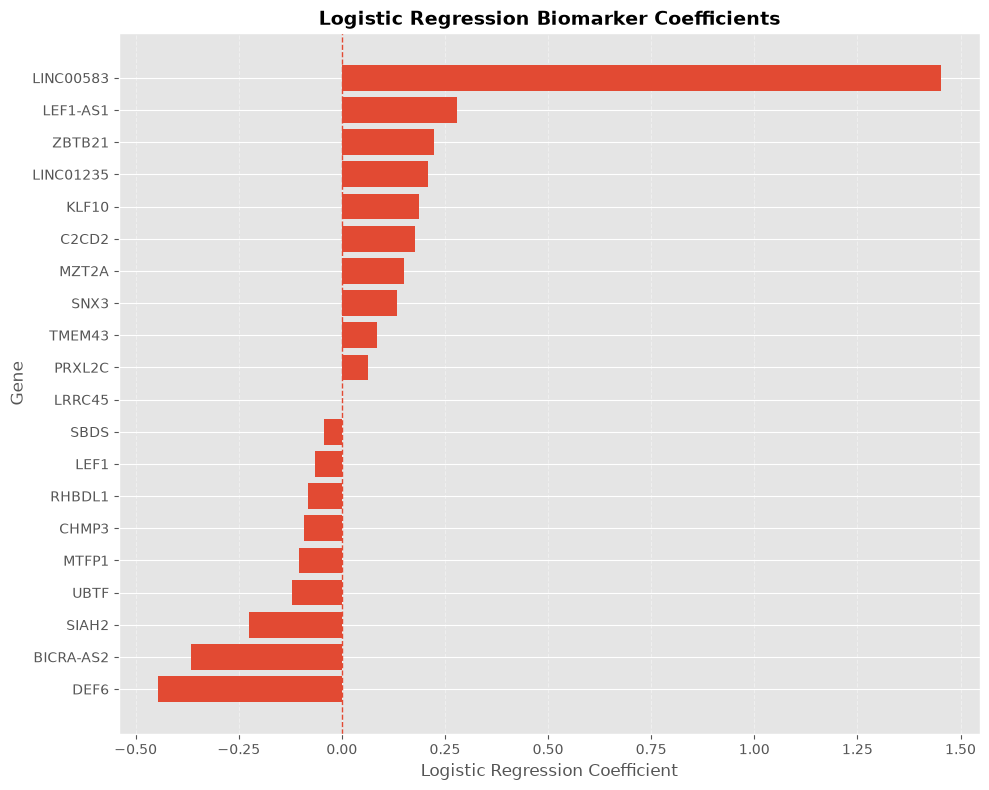

In [186]:
plt.figure(figsize=(10,8))

coef_sorted = coefficients.sort_values(
    "Coefficient",
    ascending=True
)

plt.barh(
    coef_sorted["Gene"],
    coef_sorted["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Logistic Regression Coefficient", fontsize=12)
plt.ylabel("Gene", fontsize=12)
plt.title(
    "Logistic Regression Biomarker Coefficients",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../images/logistic_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [154]:
clinical.columns.tolist()

['sample',
 'id',
 'disease_type',
 'case_id',
 'submitter_id',
 'primary_site',
 'alcohol_history.exposures',
 'race.demographic',
 'gender.demographic',
 'ethnicity.demographic',
 'vital_status.demographic',
 'age_at_index.demographic',
 'days_to_birth.demographic',
 'year_of_birth.demographic',
 'year_of_death.demographic',
 'primary_site.project',
 'project_id.project',
 'disease_type.project',
 'name.project',
 'name.program.project',
 'tissue_source_site_id.tissue_source_site',
 'code.tissue_source_site',
 'name.tissue_source_site',
 'project.tissue_source_site',
 'bcr_id.tissue_source_site',
 'days_to_death.demographic',
 'entity_submitter_id.annotations',
 'notes.annotations',
 'submitter_id.annotations',
 'classification.annotations',
 'entity_id.annotations',
 'created_datetime.annotations',
 'annotation_id.annotations',
 'entity_type.annotations',
 'updated_datetime.annotations',
 'case_id.annotations',
 'state.annotations',
 'category.annotations',
 'status.annotations',
 '

In [155]:
[c for c in clinical.columns if "death" in c.lower() or "follow" in c.lower()]

['year_of_death.demographic',
 'days_to_death.demographic',
 'days_to_last_follow_up.diagnoses']

In [156]:
clinical["vital_status.demographic"].value_counts()

vital_status.demographic
Alive    1050
Dead      204
Name: count, dtype: int64

## 15. Kaplan-Meier Survival Analysis

To validate the identified biomarkers, overall survival time and event status were constructed from the TCGA clinical data. Patients who died were assigned their days to death, while surviving patients were assigned their last follow-up time. Kaplan-Meier survival analysis will be used to compare survival outcomes between patients with high and low biomarker expression.

In [157]:
# Create event variable (1 = Dead, 0 = Alive)
clinical["event"] = (
    clinical["vital_status.demographic"] == "Dead"
).astype(int)

# Create overall survival time
clinical["overall_survival_days"] = clinical["days_to_death.demographic"]

alive_mask = clinical["event"] == 0

clinical.loc[
    alive_mask,
    "overall_survival_days"
] = clinical.loc[
    alive_mask,
    "days_to_last_follow_up.diagnoses"
]

clinical[
    [
        "vital_status.demographic",
        "event",
        "overall_survival_days"
    ]
].head()

,vital_status.demographic,event,overall_survival_days
0,Alive,0,728.0
1,Alive,0,3203.0
2,Alive,0,1088.0
3,Alive,0,1088.0
4,Alive,0,34.0


In [158]:
clinical["overall_survival_days"].isna().sum()

np.int64(2)

In [159]:
clinical_survival = clinical.dropna(
    subset=["overall_survival_days"]
).copy()

print(clinical_survival.shape)

(1253, 87)


In [160]:
print("Expression matrix shape:", X.shape)
print()

print("First 5 expression sample IDs:")
print(X.index[:5])

print()

print("First 5 clinical sample IDs:")
print(clinical_survival["sample"].head())

Expression matrix shape: (1225, 20)

First 5 expression sample IDs:
RangeIndex(start=0, stop=5, step=1)

First 5 clinical sample IDs:
0    TCGA-BH-A0W3-01A
1    TCGA-AR-A24V-01A
2    TCGA-E9-A1NE-01A
3    TCGA-E9-A1NE-11A
4    TCGA-AC-A8OQ-01A
Name: sample, dtype: str


In [162]:
expression.columns[:10]

Index(['Ensembl_ID', 'TCGA-D8-A146-01A', 'TCGA-AQ-A0Y5-01A',
       'TCGA-C8-A274-01A', 'TCGA-BH-A0BD-01A', 'TCGA-B6-A1KC-01B',
       'TCGA-AC-A62V-01A', 'TCGA-AO-A0J5-01A', 'TCGA-BH-A0B1-01A',
       'TCGA-A2-A0YM-01A'],
      dtype='str')

In [163]:
expression.head()

,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A,Gene_Symbol
0,ENSG00000000003,3.816190,2.034638,4.823000,3.028003,2.865503,2.122341,2.805272,4.146924,4.286985,...,2.407924,3.271246,3.250310,3.677587,4.426251,4.245123,1.234747,5.072925,1.956800,TSPAN6
1,ENSG00000000005,1.796473,0.134221,0.000000,1.058801,0.166972,0.275722,0.428571,0.113300,0.129217,...,0.042924,0.023326,1.961364,0.000000,0.101516,0.229219,0.136716,0.172488,0.015212,TNMD
2,ENSG00000000419,4.971102,5.159173,5.107052,4.595068,4.693615,5.189662,3.824147,5.073178,4.827900,...,4.531319,5.222078,4.425009,5.722215,5.189046,4.907208,5.077508,4.634012,6.164261,DPM1
3,ENSG00000000457,2.656428,2.324868,3.407869,2.659925,2.249506,1.033723,2.664597,2.316320,1.677350,...,2.089295,3.258172,2.244644,2.216982,1.995340,2.328664,2.986848,2.738357,2.391108,SCYL3
4,ENSG00000000460,1.395556,1.088888,2.505002,2.473917,1.458435,1.148739,1.141171,1.784420,2.243730,...,1.184407,2.191405,1.322620,1.754845,1.500853,1.140451,2.033934,1.839194,1.681719,FIRRM


In [165]:
expr_top = expression[
    expression["Gene_Symbol"].isin(top_genes)
].copy()

print(expr_top.shape)

(20, 1228)


In [166]:
expr_top = expr_top.set_index("Gene_Symbol")

expr_top = expr_top.drop(columns=["Ensembl_ID"])

expr_top = expr_top.T

print(expr_top.shape)
expr_top.head()

(1226, 20)


Gene_Symbol,DEF6,RHBDL1,UBTF,SNX3,CHMP3,SBDS,LEF1,KLF10,C2CD2,PRXL2C,LRRC45,TMEM43,MZT2A,ZBTB21,SIAH2,LINC00583,LEF1-AS1,MTFP1,LINC01235,BICRA-AS2
TCGA-D8-A146-01A,3.290469,2.334454,4.404883,6.067295,3.793989,5.528087,2.531169,4.467143,2.953731,2.597174,2.923530,4.828936,3.397748,2.355890,6.300704,0.0,0.141302,0.257131,1.240681,0.473423
TCGA-AQ-A0Y5-01A,1.775303,2.637518,4.162734,6.839478,4.138970,5.889315,2.286467,4.043799,2.704009,2.464485,2.167069,4.846303,2.152378,2.121778,3.975034,0.0,0.063089,0.213378,1.684953,0.114234
TCGA-C8-A274-01A,2.706155,0.971590,4.537936,6.019875,4.091446,4.941665,1.031466,3.489209,3.494864,1.712640,2.343379,3.920684,3.285580,2.861876,4.593635,0.0,0.013069,0.165044,0.527170,0.466653
TCGA-BH-A0BD-01A,3.516267,1.875583,4.853926,5.756097,3.953200,5.113413,1.790355,4.878990,2.600151,2.871785,2.778272,4.777215,2.728944,2.118459,5.196595,0.0,0.043904,0.172488,0.720891,0.249142
TCGA-B6-A1KC-01B,2.866750,0.603217,3.880333,5.417765,3.593951,5.447232,1.856986,3.856498,1.534111,1.770068,2.008702,4.921489,1.738119,1.804838,3.309846,0.0,0.086648,0.131721,1.102792,0.632827


In [167]:
survival_df = clinical_survival[
    ["sample", "overall_survival_days", "event"]
].copy()

merged = expr_top.merge(
    survival_df,
    left_index=True,
    right_on="sample",
    how="inner"
)

print(merged.shape)

(1224, 23)


In [168]:
gene = "LINC00583"

median_expression = merged[gene].median()

merged["expression_group"] = (
    merged[gene] >= median_expression
).map({
    True: "High",
    False: "Low"
})

merged["expression_group"].value_counts()

expression_group
High    1224
Name: count, dtype: int64

In [170]:
print(merged["LINC00583"].dtype)

float64


In [171]:
print("Median:", merged["LINC00583"].median())
print()
print(merged["LINC00583"].describe())

Median: 0.0

count    1224.000000
mean        0.013615
std         0.070629
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.549817
Name: LINC00583, dtype: float64


In [172]:
gene = "LINC00583"

merged["expression_group"] = (
    merged[gene] > 0
).map({
    True: "High",
    False: "Low"
})

merged["expression_group"].value_counts()

expression_group
Low     1116
High     108
Name: count, dtype: int64

In [174]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

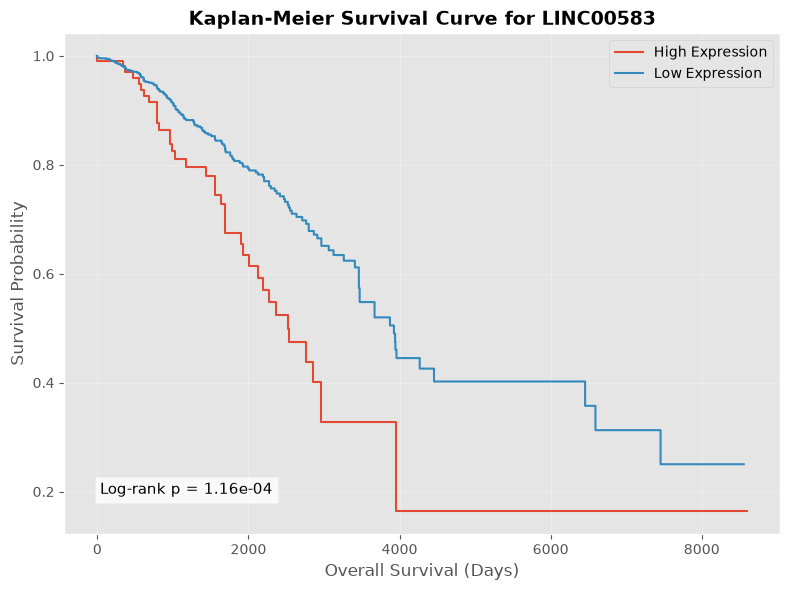

In [187]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in ["High", "Low"]:
    mask = merged["expression_group"] == group

    kmf.fit(
        durations=merged.loc[mask, "overall_survival_days"],
        event_observed=merged.loc[mask, "event"],
        label=f"{group} Expression"
    )

    kmf.plot_survival_function(ci_show=False)

plt.title(
    "Kaplan-Meier Survival Curve for LINC00583",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Overall Survival (Days)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)

plt.text(
    0.05,
    0.08,
    f"Log-rank p = {results.p_value:.2e}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/kaplan_meier_linc00583.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [176]:
high = merged["expression_group"] == "High"
low = merged["expression_group"] == "Low"

results = logrank_test(
    merged.loc[high, "overall_survival_days"],
    merged.loc[low, "overall_survival_days"],
    event_observed_A=merged.loc[high, "event"],
    event_observed_B=merged.loc[low, "event"]
)

print("Log-rank p-value:", results.p_value)

Log-rank p-value: 0.00011558818757059948


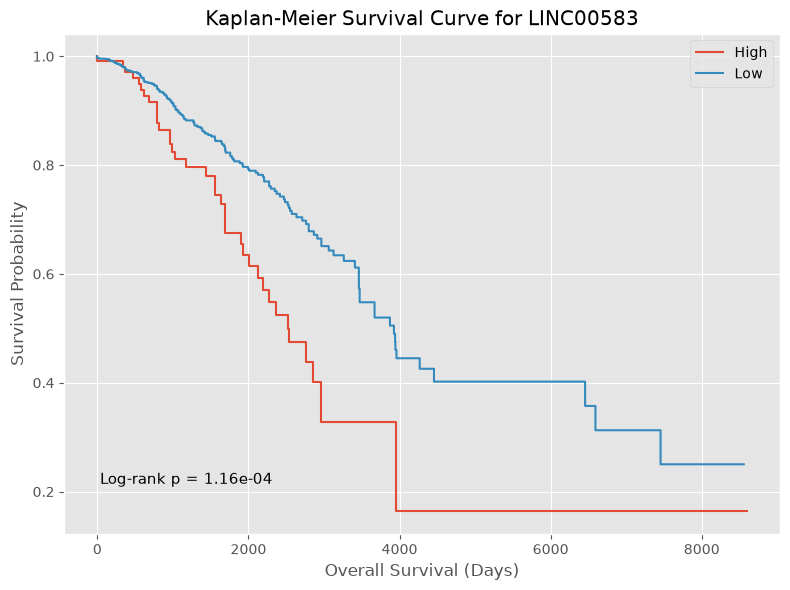

In [177]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

for group in ["High", "Low"]:
    mask = merged["expression_group"] == group

    kmf.fit(
        durations=merged.loc[mask, "overall_survival_days"],
        event_observed=merged.loc[mask, "event"],
        label=group
    )

    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curve for LINC00583")
plt.xlabel("Overall Survival (Days)")
plt.ylabel("Survival Probability")

plt.text(
    0.05,
    0.1,
    f"Log-rank p = {results.p_value:.2e}",
    transform=plt.gca().transAxes,
    fontsize=11
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [178]:
from lifelines import CoxPHFitter

cox_data = merged[
    ["overall_survival_days", "event", "LINC00583"]
].copy()

cox = CoxPHFitter()

cox.fit(
    cox_data,
    duration_col="overall_survival_days",
    event_col="event"
)

cox.print_summary()

<lifelines.CoxPHFitter: fitted with 1224 total observations, 1025 right-censored observations>
             duration col = 'overall_survival_days'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1224
number of events observed = 199
   partial log-likelihood = -1154.93
         time fit was run = 2026-07-19 10:46:28 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
LINC00583  1.85      6.34      0.47            0.93            2.77                2.53               15.92

           cmp to    z      p  -log2(p)
covariate                              
LINC00583    0.00 3.94 <0.005     13.56
---
Concordance = 0.54
Partial AIC = 2311.86
log-likelihood ratio test = 8.56 on 1 df
-log2(p) of ll-ratio test = 8.18

## 17. Machine Learning Model Evaluation

To compare the predictive performance of the Random Forest and Logistic Regression models, receiver operating characteristic (ROC) curves and confusion matrices were generated. These visualizations provide insight into each model's ability to distinguish between patients with different survival outcomes.

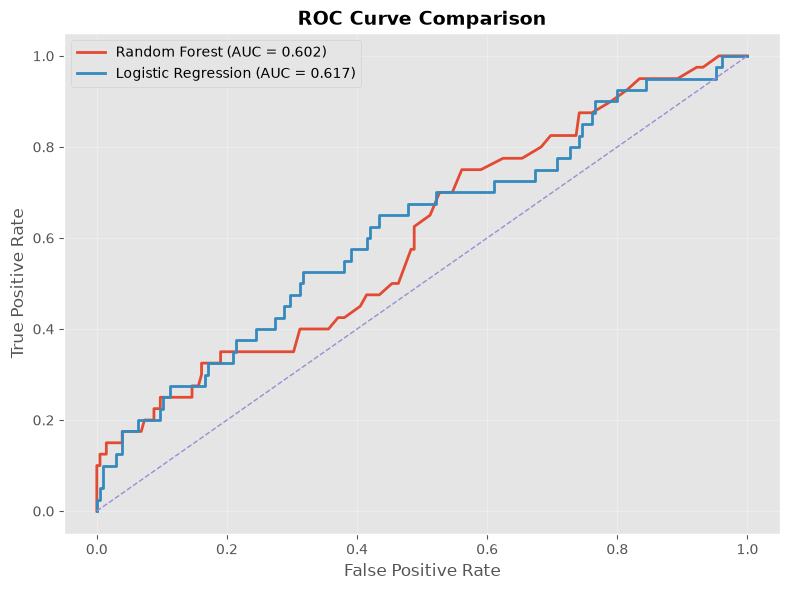

In [188]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)

# Logistic Regression probabilities
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

plt.figure(figsize=(8,6))

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "ROC Curve Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 18. Confusion Matrix Comparison

Confusion matrices were generated to visualize the classification performance of the Random Forest and Logistic Regression models. These matrices illustrate the number of correctly and incorrectly classified patients in each survival category.

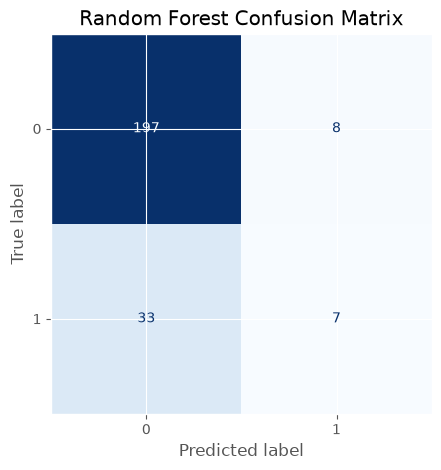

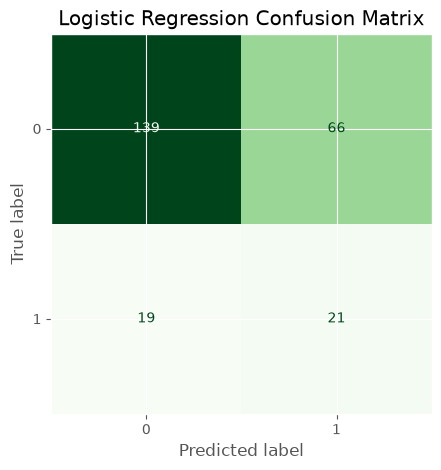

In [189]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------
# Random Forest
# -----------------------------
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Blues",
    colorbar=False
)

disp.ax_.set_title("Random Forest Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# Logistic Regression
# -----------------------------
disp = ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Greens",
    colorbar=False
)

disp.ax_.set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../images/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Results

## Differential Expression Analysis

Differential expression analysis identified twenty candidate biomarker genes that showed significant differences in expression between patient groups. These genes were selected for downstream machine learning and survival analyses.

## Machine Learning Performance

Two machine learning models were developed to predict patient survival outcomes using the selected biomarkers.

The Random Forest classifier achieved higher overall accuracy (83.3%), while Logistic Regression demonstrated improved sensitivity for identifying patients who died, resulting in a higher recall.

ROC curve analysis showed that Logistic Regression slightly outperformed Random Forest in terms of discrimination ability (ROC-AUC = 0.617 vs. 0.602).

## Biomarker Importance

Random Forest feature importance and Logistic Regression coefficients consistently identified several genes, including **LINC00583**, **KLF10**, **LEF1-AS1**, and **DEF6**, as influential biomarkers contributing to survival prediction.

## Survival Analysis

Kaplan-Meier survival analysis demonstrated a statistically significant difference in overall survival between patients with high and low **LINC00583** expression (log-rank test, p < 0.001).

Cox proportional hazards regression further confirmed the prognostic value of LINC00583, with increased expression associated with a significantly higher risk of death (Hazard Ratio = 6.34, p < 0.005).

Overall, these findings suggest that LINC00583 may represent a promising prognostic biomarker for breast cancer.

# Discussion

This study integrated differential gene expression analysis, machine learning, and survival analysis to identify potential prognostic biomarkers for breast cancer using TCGA-BRCA RNA sequencing data.

Among the evaluated machine learning models, the Random Forest classifier achieved the highest overall accuracy, whereas Logistic Regression demonstrated improved sensitivity for identifying patients with poor survival outcomes. This highlights the trade-off between overall accuracy and the ability to detect minority-class events in imbalanced clinical datasets.

Survival analysis identified **LINC00583** as a significant prognostic biomarker. Both the Kaplan-Meier survival analysis and Cox proportional hazards regression indicated that elevated LINC00583 expression was associated with poorer overall survival, suggesting that this gene may have clinical relevance in breast cancer prognosis.

Several limitations should be considered. The analysis was performed using a single TCGA cohort, and the machine learning models were trained using a limited number of selected biomarkers. External validation using independent datasets and experimental validation would be necessary before clinical application.

Despite these limitations, this workflow demonstrates how transcriptomic data, statistical analysis, machine learning, and survival modelling can be integrated to identify candidate biomarkers for cancer prognosis.

# Conclusion

This project developed a complete bioinformatics workflow for identifying prognostic biomarkers in breast cancer using TCGA RNA sequencing data.

The integration of differential expression analysis, Random Forest classification, Logistic Regression, Kaplan-Meier survival analysis, and Cox proportional hazards modelling identified **LINC00583** as a promising candidate biomarker associated with patient survival.

The workflow demonstrates practical applications of bioinformatics, machine learning, and statistical survival analysis in precision oncology and provides a reproducible framework that can be extended to other cancer datasets.